
## NIO and cost






## Inputs



(2, 'i_h2i_rate')

(3, 'i_pci_rate')

(5, 'i_ngi_rate')

(6, 'i_o2_volfract')

(8, 'i_h2_temp')

(9, 'i_hbtemp')

(10, 'i_wind_rt')


## Outputs


* desired output requirements 


(27, 'o_tgt')

(29, 'o_hmt')

(39, 'o_prod_rt')

(40, 'o_fta')

(28, 'o_coke_rt')



In [1]:

## !pip install xgboost
## !pip install onnxmltools
## !pip install onnxruntime
## !pip install pandas
## !pip install scikit-learn
## !pip install matplotlib
## !pip install seaborn
## !pip install mlxtend
## ! pip install skl2onnx



In [2]:


import torch
import numpy as np
import pandas as pd
import sklearn
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import math
import seaborn as sns
import random
import functorch


import torch.optim as optim


from numpy.random import normal
from scipy.stats import norm
import scipy.stats as stats
from numpy import hstack
from numpy import vstack
from numpy import exp
from sklearn.neighbors import KernelDensity

##from typing import Optional

from torch import Tensor


from torch.utils.data import TensorDataset, DataLoader

from mlxtend.plotting import heatmap

## coefficient of determination (R**2)
from sklearn.metrics import r2_score

np.set_printoptions(suppress=True)
torch.set_printoptions(sci_mode=False)

import os, json, time, uuid


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score





In [9]:


import xgboost as xgb
from xgboost import XGBClassifier, XGBRegressor, DMatrix, train as train_xgb
from sklearn.datasets import load_boston
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import onnxmltools
from onnxmltools.convert.xgboost.operator_converters.XGBoost import (
    convert_xgboost)
from onnxmltools.convert import convert_xgboost as convert_xgboost_booster


from zipfile import ZipFile
from skl2onnx.common.data_types import FloatTensorType
from skl2onnx import convert_sklearn, to_onnx, update_registered_converter
from skl2onnx.common.shape_calculator import (
    calculate_linear_classifier_output_shapes,
    calculate_linear_regressor_output_shapes)


# Import the ONNX runtime environment
import onnxruntime as rt




In [10]:

import PDFshapingUtils as PDF_tk


In [11]:

PDFshapingOBJ = PDF_tk.PDFshapingUtils()


In [12]:

PDFshapingOBJ.read_csv_file_with_pandas('CFD.16.2025.csv')


In [13]:

## Ty suggested fix where 0 needs to be 300

PDFshapingOBJ.CFD_raw_data["i_h2_temp"] = PDFshapingOBJ.CFD_raw_data["i_h2_temp"].replace(0, 300)


In [14]:

PDFshapingOBJ.CFD_raw_data


,index,case name,i_h2i_rate,i_pci_rate,i_wpi_rate,i_ngi_rate,i_o2_volfract,i_ng_temp,i_h2_temp,i_hbtemp,...,o_h2o_sollos,o_feo_sollos,o_hm_rt,o_mw_rt,o_wf_rt,o_hm_h2share,o_mw_h2share,o_wf_h2share,o_prod_rt,o_fta
0,1,H2-0_PCI-0_WPI-0_NG-120_O2-21_NGT-300_H2T-0_HB...,0,0,0,120,21,300,300,1200,...,20.0,44.9,122.0,264.0,687.0,31.6,26.7,63.5,4050.0,1800.0
1,2,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,18.5,52.6,122.0,265.0,684.0,27.9,23.4,60.6,4060.0,1850.0
2,3,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.6,50.9,123.0,266.0,690.0,27.7,23.5,60.8,4080.0,1850.0
3,4,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.2,52.2,124.0,268.0,690.0,27.7,23.2,60.6,4090.0,1850.0
4,5,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.2,52.4,124.0,268.0,695.0,27.7,23.2,60.7,4110.0,1850.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,4995,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1600,...,18.7,40.3,353.0,763.0,2190.0,34.0,20.5,56.7,11700.0,2380.0
4995,4996,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1480,...,18.7,40.7,353.0,763.0,2190.0,33.8,20.4,56.8,11700.0,2310.0
4996,4997,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1600,...,19.2,37.5,353.0,763.0,2230.0,33.6,20.4,57.1,11700.0,2380.0
4997,4998,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1480,...,17.6,39.8,355.0,768.0,2220.0,34.0,20.0,55.7,11800.0,2310.0


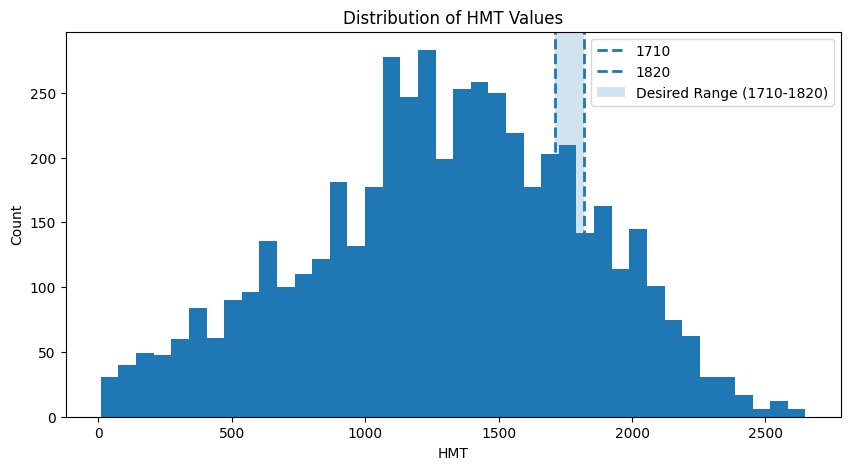

Total samples: 4999
Inside 1710-1820: 336
Percent inside: 6.72%


In [15]:

import matplotlib.pyplot as plt

df = PDFshapingOBJ.CFD_raw_data

# Histogram of HMT
plt.figure(figsize=(10,5))

plt.hist(df["o_hmt"], bins=40)

# Desired operating range
plt.axvline(1710, linestyle="--", linewidth=2, label="1710")
plt.axvline(1820, linestyle="--", linewidth=2, label="1820")

# Shade target region
plt.axvspan(1710, 1820, alpha=0.2, label="Desired Range (1710-1820)")

plt.xlabel("HMT")
plt.ylabel("Count")
plt.title("Distribution of HMT Values")
plt.legend()

plt.show()

# Optional statistics
total = len(df)
inside = ((df["o_hmt"] >= 1710) & (df["o_hmt"] <= 1820)).sum()

print(f"Total samples: {total}")
print(f"Inside 1710-1820: {inside}")
print(f"Percent inside: {100*inside/total:.2f}%")


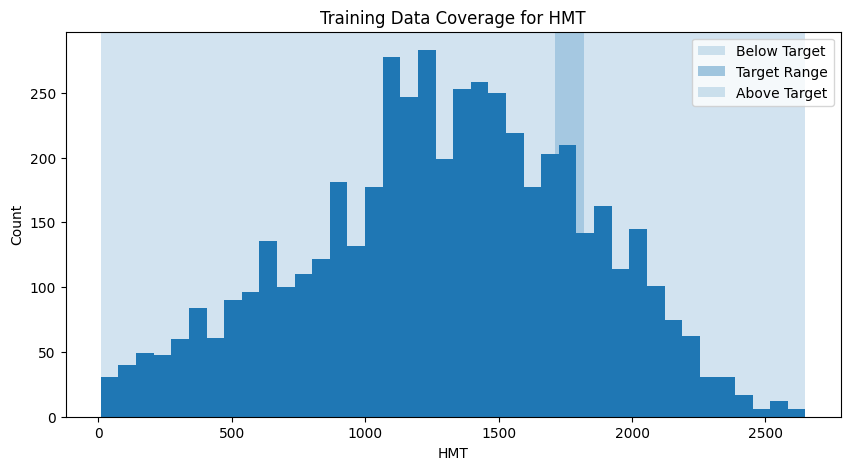

In [16]:

import matplotlib.pyplot as plt

df = PDFshapingOBJ.CFD_raw_data

hmt = df["o_hmt"]

plt.figure(figsize=(10,5))
plt.hist(hmt, bins=40)

plt.axvspan(hmt.min(), 1710, alpha=0.2, label="Below Target")
plt.axvspan(1710, 1820, alpha=0.4, label="Target Range")
plt.axvspan(1820, hmt.max(), alpha=0.2, label="Above Target")

plt.xlabel("HMT")
plt.ylabel("Count")
plt.title("Training Data Coverage for HMT")
plt.legend()

plt.show()


In [17]:

below = (df["o_hmt"] < 1710).sum()
inside = ((df["o_hmt"] >= 1710) & (df["o_hmt"] <= 1820)).sum()
above = (df["o_hmt"] > 1820).sum()

print("Below:", below, f"({100*below/len(df):.2f}%)")
print("Inside:", inside, f"({100*inside/len(df):.2f}%)")
print("Above:", above, f"({100*above/len(df):.2f}%)")


Below: 3830 (76.62%)
Inside: 336 (6.72%)
Above: 833 (16.66%)


In [18]:

PDFshapingOBJ.print_headers_list()


['index', 'case name', 'i_h2i_rate', 'i_pci_rate', 'i_wpi_rate', 'i_ngi_rate', 'i_o2_volfract', 'i_ng_temp', 'i_h2_temp', 'i_hbtemp', 'i_wind_rt', 'i_blastH2O', 'i_BdnH2O', 'i_sgi_rate', 'i_sgtemp', 'i_sgi_H2COratio', 'i_sgi_ReProRatio', 'o_tuy_velo', 'o_tuy_temp', 'o_burn', 'o_delp', 'o_co_vf', 'o_co2_vf', 'o_h2_vf', 'o_n2_vf', 'o_co_util', 'o_h2_util', 'o_tgt', 'o_coke_rt', 'o_hmt', 'o_co2_sollos', 'o_h2o_sollos', 'o_feo_sollos', 'o_hm_rt', 'o_mw_rt', 'o_wf_rt', 'o_hm_h2share', 'o_mw_h2share', 'o_wf_h2share', 'o_prod_rt', 'o_fta']
41
(0, 'index')
(1, 'case name')
(2, 'i_h2i_rate')
(3, 'i_pci_rate')
(4, 'i_wpi_rate')
(5, 'i_ngi_rate')
(6, 'i_o2_volfract')
(7, 'i_ng_temp')
(8, 'i_h2_temp')
(9, 'i_hbtemp')
(10, 'i_wind_rt')
(11, 'i_blastH2O')
(12, 'i_BdnH2O')
(13, 'i_sgi_rate')
(14, 'i_sgtemp')
(15, 'i_sgi_H2COratio')
(16, 'i_sgi_ReProRatio')
(17, 'o_tuy_velo')
(18, 'o_tuy_temp')
(19, 'o_burn')
(20, 'o_delp')
(21, 'o_co_vf')
(22, 'o_co2_vf')
(23, 'o_h2_vf')
(24, 'o_n2_vf')
(25, 'o_co_ut

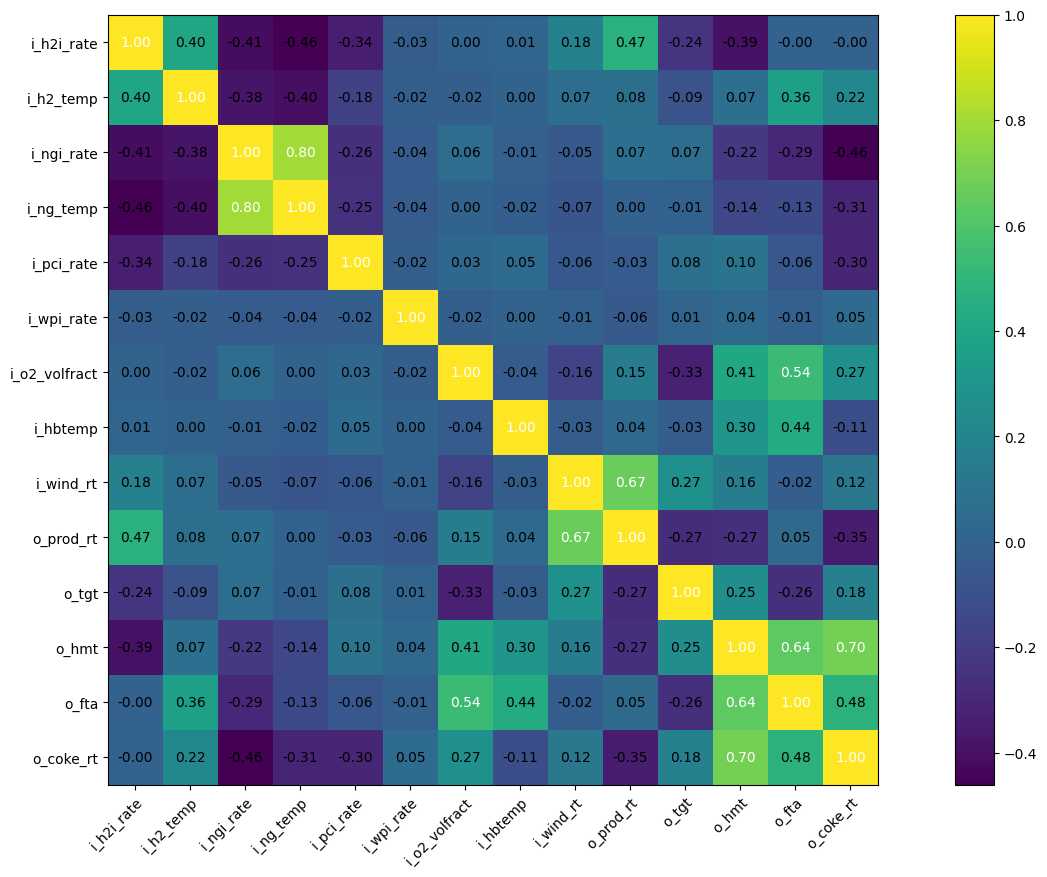

In [19]:


PDFshapingOBJ.list_of_selected_column_names = ['i_h2i_rate','i_h2_temp','i_ngi_rate','i_ng_temp','i_pci_rate',
                    'i_wpi_rate','i_o2_volfract',
                    'i_hbtemp','i_wind_rt','o_prod_rt', 'o_tgt', 'o_hmt','o_fta', 'o_coke_rt']



PDFshapingOBJ.print_correlation_coefficients()


In [20]:

PDFshapingOBJ.convert_pd_data_to_numpy()


[[1
  'H2-0_PCI-0_WPI-0_NG-120_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-7_SGI-0_SGT-0_SGC_0 '
  0 ... 63.5 4050.0 1800.0]
 [2
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-1_SGI-0_SGT-0_SGC_0 '
  0 ... 60.6 4060.0 1850.0]
 [3
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  0 ... 60.8 4080.0 1850.0]
 ...
 [4997
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1600_WR-230_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  30 ... 57.1 11700.0 2380.0]
 [4998
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1480_WR-230_MHB-5.7_BM-3_SGI-0_SGT-0_SGC_0 '
  30 ... 55.7 11800.0 2310.0]
 [4999
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1480_WR-230_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  30 ... 56.2 11800.0 2310.0]]
(4999, 41)


In [21]:

PDFshapingOBJ.gen_X_y_for_selected_indeces(  
                   inputs = [  2, 3, 5, 6, 8, 9, 10   ] , 
                   outputs= [ 27, 29, 39, 40, 28 ]   
)


## inputs = [ 2, 3, 5, 6, 8, 9, 10  ]          ## the full 7



7
5


In [22]:

print(PDFshapingOBJ.X.shape)
print(PDFshapingOBJ.y.shape)


(4999, 7)
(4999, 5)


In [23]:

PDFshapingOBJ.random_seed = int( random.random() * 100  )         ## defautl is 42


In [24]:

PDFshapingOBJ.split_np_data_train_test(selected_test_size=0.2)


(3999, 7)
(1000, 7)
(3999, 5)
(1000, 5)


In [25]:

print(PDFshapingOBJ.X_train.shape)
print(PDFshapingOBJ.X_test.shape)

print(PDFshapingOBJ.y_train.shape)
print(PDFshapingOBJ.y_test.shape)


(3999, 7)
(1000, 7)
(3999, 5)
(1000, 5)


In [26]:

'''


from sklearn.decomposition import PCA

# Instantiate PCA to reduce to 4 components
pca = PCA(n_components=4)

# Fit on training data and transform both train and test
X_train_pca = pca.fit_transform(PDFshapingOBJ.X_train)
X_test_pca  = pca.transform(PDFshapingOBJ.X_test)

# Replace the original inputs with PCA-reduced versions
PDFshapingOBJ.X_train = X_train_pca
PDFshapingOBJ.X_test  = X_test_pca


'''


'\n\n\nfrom sklearn.decomposition import PCA\n\n# Instantiate PCA to reduce to 4 components\npca = PCA(n_components=4)\n\n# Fit on training data and transform both train and test\nX_train_pca = pca.fit_transform(PDFshapingOBJ.X_train)\nX_test_pca  = pca.transform(PDFshapingOBJ.X_test)\n\n# Replace the original inputs with PCA-reduced versions\nPDFshapingOBJ.X_train = X_train_pca\nPDFshapingOBJ.X_test  = X_test_pca\n\n\n'

In [27]:

print(PDFshapingOBJ.X_train.shape)
print(PDFshapingOBJ.X_test.shape)

print(PDFshapingOBJ.y_train.shape)
print(PDFshapingOBJ.y_test.shape)


(3999, 7)
(1000, 7)
(3999, 5)
(1000, 5)


In [28]:

PDFshapingOBJ.convert_dataset_from_np_to_torch()


In [29]:

PDFshapingOBJ.standardize_X_scales()
PDFshapingOBJ.standardize_y_scales()


In [30]:


PDFshapingOBJ.gen_Dataloader_train()

PDFshapingOBJ.train_dl



## Model Forward ( 7x4 )


In [31]:

n_inputs  = 7     ## 7
n_outputs = 5




#############################################################
##   F1      plus       F2
## Linear     +      Nonlinear

class F1plusF2_SIO_Forward(nn.Module):
    ## initialize the layers
    def __init__(self, x_means, x_deviations, y_means, y_deviations,  device='cuda'):
        super().__init__()
        self.device = device
        
        ## self.x_means      = x_means
        ## self.x_deviations = x_deviations
        ## self.y_means      = y_means
        ## self.y_deviations = y_deviations
        
        
        self.x_means      = x_means.to(self.device)
        self.x_deviations = x_deviations.to(self.device)
        self.y_means      = y_means.to(self.device)
        self.y_deviations = y_deviations.to(self.device)
        
        
        
        ## F1
        self.f1_linear1 = nn.Linear(n_inputs, n_outputs)       
        
        ## F2
        self.f2_linear1 = nn.Linear(n_inputs, 10)
        self.f2_act1    = nn.Tanh()   ## nn.Sigmoid()    ## Tanh()    nn.ReLU()                 
        self.f2_linear2 = nn.Linear(10, n_outputs)       
        self.f2_dropout = nn.Dropout(0.25)
        
        # Move model to device
        self.to(self.device)
        
        
    ## perform inference
    def forward(self, x):
        x = x.to(self.device)
        x = (x - self.x_means) / self.x_deviations
        
        ## F1
        f1 = self.f1_linear1(x)
        
        ## F2
        f2 = self.f2_linear1(x)
        f2 = self.f2_act1(f2)
        f2 = self.f2_dropout(f2)
        f2 = self.f2_linear2(f2)
        
        
        y_scaled   = f1 + f2
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        ##   y_descaled = torch.clamp(  y_descaled, min=0.0  )
        
        return y_descaled, y_scaled
    




In [32]:

n_inputs  = 7    ## 7
n_outputs = 5





    
class ResidualNet_Forward(nn.Module):
    def __init__(self, x_means, x_deviations, y_means, y_deviations, dropout_rate=0.1, device='cuda'):
        
        super().__init__()
        self.device = device
        
        self.x_means      = x_means.to(self.device)
        self.x_deviations = x_deviations.to(self.device)
        self.y_means      = y_means.to(self.device)
        self.y_deviations = y_deviations.to(self.device)

     
        self.fc1  = nn.Linear(n_inputs, 64)
        self.act1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_rate)

        self.fc2 = nn.Linear(64, 64)
        self.act2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout_rate)

        self.fc3 = nn.Linear(64, n_outputs)

        # If input_dim ≠ 64, project for residual addition
        self.input_proj = nn.Linear(n_inputs, 64) if n_inputs != 64 else nn.Identity()
        
        # Move model to device
        self.to(self.device)
        

    def forward(self, x):
        x  = x.to(self.device)
        x  = (x - self.x_means) / self.x_deviations
        x0 = self.input_proj(x)
        x1 = self.dropout1(self.act1(self.fc1(x)))
        x2 = self.dropout2(self.act2(self.fc2(x1)))
        x_res = x2 + x0
        y_scaled = self.fc3(x_res)
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        return y_descaled, y_scaled
    

    


In [33]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## model_Forward     = F1plusF2_SIO_Forward(

model_Forward     =     F1plusF2_SIO_Forward(
                         PDFshapingOBJ.x_means, 
                         PDFshapingOBJ.x_deviations, 
                         PDFshapingOBJ.y_means, 
                         PDFshapingOBJ.y_deviations,
                         device=device  # pass device into the model
    
)

optimizer = optim.Adam(model_Forward.parameters(), lr=0.001)
loss_fn   = nn.MSELoss()



In [34]:

model_Forward.train()

for epoch in range(1000):
    for xb, yb in PDFshapingOBJ.train_dl:
        
        xb = xb.to(model_Forward.device)
        yb = yb.to(model_Forward.device)
        
        optimizer.zero_grad()
        pred_descaled, pred_scaled = model_Forward(xb)
        
        loss = loss_fn(pred_scaled, yb)
        loss.backward()
        optimizer.step()
    if epoch % 100 == 0:
        print(epoch, ".....", loss.item() ) 
    



0 ..... 0.5860731601715088
100 ..... 0.14506950974464417
200 ..... 0.21302294731140137
300 ..... 0.15457850694656372
400 ..... 0.19840070605278015
500 ..... 0.5964189767837524
600 ..... 0.3016956150531769
700 ..... 0.3761049509048462
800 ..... 0.3306748569011688
900 ..... 0.2667545974254608


In [35]:

print("=== SANITY CHECK: SCALING ===")
print("y_means:", PDFshapingOBJ.y_means)
print("y_deviations:", PDFshapingOBJ.y_deviations)

print("===============================================")

print("x_means:", PDFshapingOBJ.x_means)
print("x_deviations:", PDFshapingOBJ.x_deviations)


=== SANITY CHECK: SCALING ===
y_means: tensor([[  97.8900, 1302.9089, 8443.0947, 2307.7390,  417.6642]])
y_deviations: tensor([[  50.4776,  524.3766, 1510.8207,  212.7185,   50.0174]])
x_means: tensor([[  12.6182,   18.8525,   40.8030,   25.6239,  415.7539, 1440.0300,
          198.6759]])
x_deviations: tensor([[ 15.3816,  45.2972,  46.4567,   3.3317, 271.6318, 157.8219,  26.4768]])


In [36]:

print(PDFshapingOBJ.y_means -  PDFshapingOBJ.y_deviations)
print(PDFshapingOBJ.y_means +  PDFshapingOBJ.y_deviations)


tensor([[  47.4125,  778.5323, 6932.2739, 2095.0205,  367.6468]])
tensor([[ 148.3676, 1827.2855, 9953.9150, 2520.4575,  467.6815]])


In [37]:

print(PDFshapingOBJ.x_means -  PDFshapingOBJ.x_deviations)
print(PDFshapingOBJ.x_means +  PDFshapingOBJ.x_deviations)


tensor([[  -2.7634,  -26.4447,   -5.6537,   22.2922,  144.1222, 1282.2081,
          172.1991]])
tensor([[  27.9997,   64.1497,   87.2596,   28.9556,  687.3857, 1597.8519,
          225.1527]])


In [38]:

import numpy as np
from numpy.linalg import norm

# --- distance function ---
def euclid(a, b):
    return norm(a - b)



## Costs




## Inputs



(2, 'i_h2i_rate')

(3, 'i_pci_rate')

(5, 'i_ngi_rate')

(6, 'i_o2_volfract')

(8, 'i_h2_temp')

(9, 'i_hbtemp')

(10, 'i_wind_rt')


## Outputs


* desired output requirements 


(27, 'o_tgt')

(29, 'o_hmt')

(39, 'o_prod_rt')

(40, 'o_fta')

(28, 'o_coke_rt')




In [39]:



def cost_func_h2i_rate(H2_rate=10, PCI_rate=25, H2_temp=600):
    
    E22        = H2_rate
    E23        = PCI_rate
    E26        = H2_temp
    
    
    ## E22        = 10       ## Starter variable  H2 rate
    ## E23        = 25       ## Starter variable PCI rate
    ## E26        = 600      ## Starter variable H2 temp
    
    ############################
    
    E6         = 0.0143 * 0.02
    
    H6         = E6 * E26
    
    E4         = 2
    
    E5         = E4 + H6
    
    
    
    H2_ambient =  E4 * E22
    H2_heated  =  E5 * E23
    H2_temp    =  E6 * E26
    
    
    
    
    result = H2_ambient + H2_heated + H2_temp
    
    return result



cost_func_h2i_rate()



74.4616

In [40]:

## Oxygen Enrichment in Wind



def cost_func_o2_volfract( wind_rate=195, o2=0.215, prod_rate=5775):
    
    o2 = o2 / 100.0
    
    
    '''
    print("wind_rate=195")
    print("o2=0.215")
    print("prod_rate=5775")
    
    print(wind_rate)
    print(o2)
    print(prod_rate)
    '''
    
    
    E20          = wind_rate
    E25          = o2 
    E19          = prod_rate 
    
    ## E20          = 195            ## Starter variable wind rate
    ## E25          = 0.215          ## Starter variable O2 
    ## E19          = 5775           ## Starter variable production rate 
    
    ######################################
    
    H25          = (E25 - 0.21) * E20
    
    
    K25          = H25 * 60 * 24
    
    N25          = K25 / E19
    
    E9           = 0.01 * 1000
    
    result       = E9 * N25
    
    
    return result



cost_func_o2_volfract()



-101.06368831168831

In [41]:




def cost_func_pci_rate(PCI_rate=25):
    
    E23         = PCI_rate
    
    ## E23         = 25        ## Start variable PCI rate
    
    #########################
    
    E7          = 0.3
    
    result      = E7 * E23
    
    return result



cost_func_pci_rate()



7.5

In [42]:


def cost_func_ngi_rate( NG_rate=70 ):
    
    E24    = NG_rate
    
    ## E24    = 70         ## Start variable - NG rate
    
    #############################
    
    
    E8     = 0.20
    
    result = E8 * E24
    
    
    return result



cost_func_ngi_rate()


14.0

In [43]:



def cost_func_coke_rate( coke_rate=470 ):
    
    
    E21         = coke_rate
    
    ## E21         = 470      ## Start variable coke rate
    
    ########################
    

    E12         = 0.45
    
    result      = E12 * E21 
    
    return result


cost_func_coke_rate()


211.5

In [44]:



def cost_func_wind_rate( wind_rate=195, prod_rate=5775 ):
    
    
    E20       = wind_rate
    E19       = prod_rate
    
    
    ## E20       = 195         ## start variable wind rate
    ## E19       = 5775        ## start variable production rate
    
    ##########################
    

    E11       = 0.1
    
    
    H20       = E20 * 60
    K20       = H20 * 24
    
    
    N20       = K20 / E19
    
    result    = E11 * N20
    
    return result



cost_func_wind_rate()


4.862337662337662

In [45]:

def calculate_new_loss_costs_equations(x_temp, y_DEscaled):
    
    ## x_temp
    ## "i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt"
    
    
    ## y_DEscaled
    ## "o_tgt, o_hmt, o_prod_rt, o_fta, o_coke_rt"
    
    
    ## print( x_temp.shape )
    ## print( y_DEscaled.shape )
    
    ##################################################################
    
    
    ## H2_rate=10, PCI_rate=25, H2_temp=600
    ## aa = cost_func_h2i_rate( x_temp[:,0], x_temp[:,1], x_temp[:,4])
    
    ##  wind_rate=195, o2=0.215, prod_rate=5775
    ## bb = cost_func_o2_volfract( x_temp[:,6], x_temp[:,3], y_DEscaled[:,2])
    
    ## PCI_rate=25
    ## cc = cost_func_pci_rate( x_temp[:,1] )
    
    ## NG_rate=70
    ## dd = cost_func_ngi_rate( x_temp[:,2] )
    
    ## coke_rate=470
    ## ee = cost_func_coke_rate( y_DEscaled[:,4] )
    
    ## wind_rate=195, prod_rate=5775
    ## ff = cost_func_wind_rate( x_temp[:,6], y_DEscaled[:,2] )
    
    ####################################################################
    
    res = 0.0  ## + aa + bb + cc + dd + ee + ff
    
    
    return res



## Now add Costs


In [46]:

def regularize_z(z, strength=1e-3):
    
    return strength * torch.sum(z**2)


In [47]:

def soft_box_penalty(x, lower, upper, strength=1.0):     ## strength=10.0
    
    return strength * ((torch.relu(lower - x) ** 2).sum() + (torch.relu(x - upper) ** 2).sum())


In [48]:

def soft_box_penalty2(x, lower, upper, beta=0.01):
    
    # original constraint penalty
    violation = (torch.relu(lower - x)**2 + torch.relu(x - upper)**2).sum()
    
    # NEW: center stabilizer
    center      = (lower + upper) / 2
    center_pull = ((x - center)**2).mean()
    
    return violation + beta * center_pull


In [49]:

clamp_min = torch.tensor([[   0,   0,   0,    21,   300,   1200, 150 ]])     ## from Ty
clamp_max = torch.tensor([[ 300, 300, 300,    90,  1200,   1500, 220 ]])


get_x_from_z = lambda z: clamp_min + (clamp_max - clamp_min) * torch.sigmoid(z)


In [50]:

##                                   1710
y_clamp_min = torch.tensor([[  100,  1710,   6400,    2000,   200 ]])     ## from Ty
y_clamp_max = torch.tensor([[  150,  1820,   6600,    2600,   500 ]])


y_clamp_min_normalized =  (y_clamp_min  - PDFshapingOBJ.y_means) /  PDFshapingOBJ.y_deviations
y_clamp_max_normalized =  (y_clamp_max  - PDFshapingOBJ.y_means) /  PDFshapingOBJ.y_deviations


In [51]:

def wrapped_model(x):
    y_descaled, _ = model_Forward(x)
    return y_descaled  



In [52]:

'''

price_real    = np.array([4.0, 0.24, 0.17, 0.0, 0.0, 0.0, 0.0])
price_real    = torch.tensor(price_real, dtype=torch.float32)

price_real_y5 = np.array([0.0, 0.0, 0.0, 0.0, 0.25])
price_real_y5 = torch.tensor(price_real_y5, dtype=torch.float32)


'''



'\n\nprice_real    = np.array([4.0, 0.24, 0.17, 0.0, 0.0, 0.0, 0.0])\nprice_real    = torch.tensor(price_real, dtype=torch.float32)\n\nprice_real_y5 = np.array([0.0, 0.0, 0.0, 0.0, 0.25])\nprice_real_y5 = torch.tensor(price_real_y5, dtype=torch.float32)\n\n\n'

In [53]:


## "i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt"
    
## "o_tgt, o_hmt, o_prod_rt, o_fta, o_coke_rt"


price_real    = np.array([0.0, 0.3, 0.20, 0.0, 0.0, 0.0, 0.0])
price_real    = torch.tensor(price_real, dtype=torch.float32)

price_real_y5 = np.array([0.0, 0.0, 0.0, 0.0, 0.45])
price_real_y5 = torch.tensor(price_real_y5, dtype=torch.float32)


model_Forward.eval()


for p in model_Forward.parameters():
    p.requires_grad = False



In [54]:


## lambda_cost = 0.0

dist_method_A = []
dist_method_B = []
cost_diffs    = [] 
cost_diff     = 0

actual_pred_cost = []
actual_real_cost = []

percent_diffs = []
percent_diff  = 0 

learning_rate = 0.01        ## 0.001      ## 1e-5


In [55]:

def print_losses(j, cost_pred, x_temp_pred_np, cost_real, loss, loss_main, loss_cost, loss_ranges, 
                   new_loss_costs_equations, loss_hmt_norm):
    '''
    print(f"iteration {j}")
    print(f"pred cost: {cost_pred:.2f}  " ) ## "...H2, PCI, NGI:", x_temp_pred_np[:,:3] )
    print( "real cost:", cost_real)
    print( "                   loss_main(MSE)",     loss_main.item()        )
    print( "                       loss_ranges",    loss_ranges.item() )
    print("                      loss_hmt_norm",  loss_hmt_norm.item() )
    print( "                       loss_cost",      loss_cost.item() )
    print("                new_l_costs_equati", new_loss_costs_equations.item())
    print( "                       total loss",     loss.item()      )

    ## print( "                       loss_coke",  loss_coke.item() )
    '''
    
    ##############
    
    print(f"\nITERATION {j}")
    print("=" * 50)

    print(f"*** COSTS ***")
    print(f"Pred Cost : {cost_pred.item():10.2f}")
    print(f"Real Cost : {cost_real.item():10.2f}")

    print("\n*** LOSSES ***")

    metrics = [
        ("Loss Main (MSE)", loss_main.item()),
        ("Loss Ranges", loss_ranges.item()),
        ("Loss HMT Norm", loss_hmt_norm.item()),
        ("Loss Cost", loss_cost.item()),
        ("Cost Equation", new_loss_costs_equations),
        ("Total Loss", loss.item()),
    ]

    for name, value in metrics:
        print(f"{name:25s} {value:12.2f}")
    
    
   
 

In [56]:

PDFshapingOBJ.y_test[3]


array([  50., 1070., 9080., 2320.,  432.], dtype=float32)

In [57]:



import numpy as np

Y = PDFshapingOBJ.y_test
X = PDFshapingOBJ.X_test

# y2 (HMT) is column 1
y2 = Y[:, 1]

y2_min = 1710
y2_max = 1820
y2_center = (y2_min + y2_max) / 2.0  # 1765

# Rank:
# 1. Values inside range come first
# 2. Among those, closest to center (1765) come first
# 3. Outside values come after, ordered by distance from range

score = np.where(
    (y2 >= y2_min) & (y2 <= y2_max),
    np.abs(y2 - y2_center),
    1000 + np.maximum(y2_min - y2, 0) + np.maximum(y2 - y2_max, 0)
)

idx = np.argsort(score)

X_ranked = X[idx]
Y_ranked = Y[idx]

#print(Y_ranked[:20])



PDFshapingOBJ.y_test = Y_ranked
PDFshapingOBJ.X_test = X_ranked 


In [58]:

def final_data_gathering(i, wrapped_model, x_temp_pred_np, x_real_np ):
    
    print(i)
    print('*******************************************************')
    
    
    if i == 1:
        percent_errors = [ [] for _ in range(5) ]  # one list per output

    y_pred_np = wrapped_model(
                    torch.from_numpy( 
                         x_temp_pred_np
                    )).detach().numpy().flatten()
    
    y_real_np = wrapped_model(
                    torch.from_numpy(
                          x_real_np
                    )).detach().numpy().flatten()

    # % error per variable
    pct = (y_pred_np - y_real_np) / (y_real_np + 1e-8) * 100

    for k in range(5):
         percent_errors[k].append( pct[k] )
    return percent_errors


In [59]:

def print_some_values(i, x_temp_pred_np,  x_real_np, wrapped_model, PDFshapingOBJ  ):
    the_cols = "    i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt"
    '''
    print("...")
    print("...")
    print("...")
    print( the_cols )
    print( "pred" )
    print( x_temp_pred_np[0] )
    print( "real" )
    print( x_real_np )
    print("...")
    
    
    print( "o_tgt, o_hmt, o_prod_rt, o_fta, o_coke_rt" )
    print( "y pred" )
    print( wrapped_model(torch.from_numpy(x_temp_pred_np))   )
    print( "y real" )
    print(  PDFshapingOBJ.y_test[i]  )
    ## print( " this is a predicted y from the real x " )
    ## print( wrapped_model(torch.from_numpy(x_real_np))   )
    '''
    
    #################
    
    '''
    print(x_temp_pred_np)
    print(x_temp_pred_np.shape)
    print(x_real_np)
    print(x_real_np.shape)
    '''
    
    x_pred = np.round(x_temp_pred_np[0], 1)
    
    ##x_real = np.round(x_real_np, 1)
    x_real = np.round(x_real_np[0], 1)
    
    '''
    print(x_pred)
    print(x_pred.shape)
    print(x_real)
    print(x_real.shape)
    '''

    y_pred = wrapped_model(torch.from_numpy(x_temp_pred_np)).detach().cpu().numpy()[0]
    y_pred = np.round(y_pred, 1)
    
    ## print(y_pred)
    ## print(y_pred.shape)
    

    y_real = np.round(PDFshapingOBJ.y_test[i], 1)
    ## print(y_real)
    ## print(y_real.shape)


    print("\nINPUTS")
    print(f"{'Variable':15s} {'Pred':>10s} {'Real':>10s}")
    print("-"*38)

    cols_x = [
        "h2i_rate","pci_rate","ngi_rate",
        "o2_volfrac","h2_temp","hbtemp","wind_rt"
    ]

    for c,p,r in zip(cols_x, x_pred, x_real):
        print(f"{c:15s} {p:10.1f} {r:10.1f}")

    print("\nOUTPUTS")
    print(f"{'Variable':15s} {'Pred':>10s} {'Real':>10s}")
    print("-"*38)

    cols_y = [
        "tgt","hmt","prod_rt","fta","coke_rt"
    ]

    for c,p,r in zip(cols_y, y_pred, y_real):
        print(f"{c:15s} {p:10.1f} {r:10.1f}")


In [60]:

memory_history = []

import psutil
import os
import gc
import torch

def record_memory(i):

    ram_gb = psutil.Process(os.getpid()).memory_info().rss / 1024**3

    tensor_count = 0
    for obj in gc.get_objects():
        try:
            if torch.is_tensor(obj):
                tensor_count += 1
        except:
            pass

    memory_history.append(
        (
            i,
            ram_gb,
            tensor_count,
            len(gc.get_objects())
        )
    )


In [61]:


PDFshapingOBJ.y_test[:5]



array([[ 194. , 1760. , 8580. , 2220. ,  436. ],
       [ 109. , 1770. , 8130. , 2230. ,  413. ],
       [ 121. , 1770. , 7360. , 2370. ,  380. ],
       [ 135. , 1760. , 6710. , 2350. ,  429. ],
       [  58.6, 1770. , 8430. , 2280. ,  383. ]], dtype=float32)

In [62]:

PDFshapingOBJ.X_test[:5]


array([[   0.,   90.,    0.,   24.,  300., 1480.,  230.],
       [   0.,    0.,  120.,   30.,  300., 1480.,  195.],
       [   0.,  150.,    0.,   30.,  300., 1600.,  160.],
       [   0.,    0.,   80.,   30.,  300., 1480.,  160.],
       [   0.,  150.,    0.,   27.,  300., 1600.,  195.]], dtype=float32)

In [63]:

def calculate_real_costs_for_printing(loss_cost_descaled, x_temp_descaled, x_real, target_y):
    
    with torch.no_grad():
        x_temp_pred_np   = x_temp_descaled.detach().numpy()
        cost_pred        = loss_cost_descaled
        ## torch.dot(price_real, x_temp_descaled.squeeze()).item()
    
        #######################
    
        x_real = x_real.unsqueeze(0)
        target_y = target_y.unsqueeze(0)
    
        ##print(x_real.shape)
        ##print(target_y.shape)
    
        loss_cost_real          =     x_real @ price_real
        loss_cost_y5_real       =   target_y @ price_real_y5
        
        loss_wind_rate_real     = cost_func_wind_rate( x_real[:, 6], target_y[:, 2] )
        loss_h2i_rate  = cost_func_h2i_rate(x_real[:, 0], x_real[:, 1], x_real[:, 4])
        loss_o2_v    = cost_func_o2_volfract( x_real[:,6], x_real[:,3], target_y[:,2])
        
        ## loss_cost_descaled_real = loss_cost_real + loss_cost_y5_real + loss_wind_rate_real + loss_h2i_rate + loss_o2_v
    
        loss_cost_descaled_real = (
            loss_cost_real
            + loss_cost_y5_real
            + loss_wind_rate_real
            + loss_h2i_rate
            + loss_o2_v
        )
    
        #######################
        
        x_real_np        = x_real.detach().numpy() 
        cost_real        = loss_cost_descaled_real
       
    return x_temp_pred_np, x_real_np, cost_pred, cost_real


   

In [64]:

## loss_z_reg   = regularize_z(z, strength=1e-3)



In [65]:



## This may be a good one, otherwise revert to func17


def calc_dynamic_hmt_weight_func(min_y, max_y, hmt_pred, hmt_center):

    # Half-width of allowable HMT range
    scale = torch.maximum(hmt_center - min_y,
                          max_y - hmt_center)
    scale = torch.clamp(scale, min=1e-6)

    # Normalized distance from preferred HMT
    d = torch.abs(hmt_pred - hmt_center) / scale

    # Relax HMT near the center
    # 0.70 at center -> 1.00 at operating limits
    inside_weight = 0.70 + 0.30 * torch.clamp(d, max=1.0)

    # Additional penalty outside allowable range
    outside = torch.relu(min_y - hmt_pred) + \
              torch.relu(hmt_pred - max_y)

    alpha = 0.05

    outside_weight = torch.exp(alpha * outside)

    return inside_weight * outside_weight



In [66]:

print(  PDFshapingOBJ.y_test[2].shape  )
print(  PDFshapingOBJ.X_test[2].shape  )


(5,)
(7,)


In [67]:


w_mse   = 1.0
w_cost  = 1.0       
w_range = 1.0             
w_hmt   = 120.0        ## (if can't improve, use 20 and save notebook) - 10.0   (1710)   



##############################

## Go back to this
## y_clamp_min_temp         = torch.tensor([[  100,  1710 + 55,   6400,    2000,   200 ]]) 

y_clamp_min_temp            = torch.tensor([[  100,  1710 + 55,   6400,    2000,   200 ]])     
y_clamp_min_temp_normalized =  (y_clamp_min_temp  - PDFshapingOBJ.y_means) /  PDFshapingOBJ.y_deviations


for i in range(  1, PDFshapingOBJ.X_test.shape[0]  ):
    
    
    ##############################

    hmt_history = []
    
    ##############################
    
    target_y  = torch.tensor( PDFshapingOBJ.y_test[i]   )    ## what you want y ?
    x_real    = torch.tensor( PDFshapingOBJ.X_test[i]   )    ## real x
    
    target_y_normalized  = (target_y  - PDFshapingOBJ.y_means) /  PDFshapingOBJ.y_deviations
    
    
    z_init    = torch.rand((1,7))*0.2 + 0.3
    z         = torch.nn.Parameter(torch.logit(z_init))    ## this requires grad 
    optimizer = torch.optim.Adam([z], lr=learning_rate)
    
    
    for j in range(3000):              ## 2000
        
        optimizer.zero_grad()
        
        x_temp_descaled              = get_x_from_z(    z    )

        y_descaled, current_y_normalized = model_Forward( x_temp_descaled )
        
        ##########################################
        
        loss_main_norm   = torch.mean(  (current_y_normalized - target_y_normalized)**2  )
        
        ##########################################
        
        loss_ranges_norm = soft_box_penalty(current_y_normalized, y_clamp_min_normalized, y_clamp_max_normalized)
        
        ##########################################
        
        new_loss_costs_equations = 0.0
        
        loss_cost          =     x_temp_descaled @ price_real
        loss_cost_y5       =          y_descaled @ price_real_y5
        
        
        loss_wind_rate = cost_func_wind_rate( x_temp_descaled[:, 6], y_descaled[:, 2] )
        loss_h2i_rate  = cost_func_h2i_rate(x_temp_descaled[:, 0], x_temp_descaled[:, 1], x_temp_descaled[:, 4])
        loss_o2_vol    = cost_func_o2_volfract( x_temp_descaled[:,6], x_temp_descaled[:,3], y_descaled[:,2])
        
        loss_cost_descaled = loss_cost + loss_cost_y5 + loss_wind_rate + loss_h2i_rate + loss_o2_vol
        
    
        ##########################################
        # HMT is index 1 (1710)
        
        ## y_clamp_min_temp            = torch.tensor([[  100,  1710 + 55,   6400,    2000,   200 ]])     
        ## y_clamp_min_temp_normalized =  (y_clamp_min_temp  - PDFshapingOBJ.y_means) /  PDFshapingOBJ.y_deviations
        
        hmt_pred         =   current_y_normalized[:, 1]
        
        
        hmt_history.append(  hmt_pred.detach()  )
        
        
        hmt_center       =   y_clamp_min_temp_normalized[:, 1]       

        loss_hmt_norm    =      ( hmt_center - hmt_pred ) ** 2
        
        
        ################################################
        
        quad_exp_weight = 0        ## zero is off, just change to 1 for on 
        
        
        if len(hmt_history) < 50:
            hmt_dynamic_avg = hmt_pred
        else:
            hmt_dynamic_avg = torch.stack(  hmt_history[-50:]  ).mean(dim=0)



        if quad_exp_weight == 0:
            dynamic_hmt_weight = 1
        else:
            dynamic_hmt_weight = calc_dynamic_hmt_weight_func( y_clamp_min_normalized[:, 1], y_clamp_max_normalized[:, 1], hmt_dynamic_avg, hmt_center )

     
        
     
        ################################################
        
        loss_norm     = w_mse*loss_main_norm + w_range*loss_ranges_norm  + w_hmt*dynamic_hmt_weight*loss_hmt_norm
    
        ## loss_norm     = w_mse*loss_main_norm + w_range*loss_ranges_norm  + w_hmt*loss_hmt_norm 
    
        loss_descaled = w_cost*loss_cost_descaled  
        
        loss = loss_norm + loss_descaled
        
    
        
        '''
        print("loss_main_norm", loss_main_norm.item() )
        print("loss_ranges_norm", loss_ranges_norm.item() )
        print("loss_hmt_norm", loss_hmt_norm.item() )
        print("loss_cost_descaled", loss_cost_descaled.item() )
        print("new_loss_costs_equations", new_loss_costs_equations.item() )
        print("loss", loss.item() )
        input()
        '''
        
    
        loss.backward()
        optimizer.step()
        
        #####################################################################
        #####################################################################
        #####################################################################
        #####################################################################
        
        '''
        x_temp_pred_np   = x_temp_descaled.detach().numpy()
        cost_pred        = torch.dot(price_real, x_temp_descaled.squeeze()).item()
        
        x_real_np        = x_real.detach().numpy() 
        cost_real        = np.dot(price_real, x_real_np)
        '''
        
        
        x_temp_pred_np, x_real_np, cost_pred, cost_real = calculate_real_costs_for_printing(loss_cost_descaled, 
                                                                          x_temp_descaled, x_real, target_y)
        
       
        if j % 400 == 0:           
            print_losses(j, cost_pred, x_temp_pred_np, cost_real, loss, loss_main_norm, 
                              loss_cost_descaled, loss_ranges_norm, new_loss_costs_equations, loss_hmt_norm)
        
   
        #####################################################################
        cost_diff = cost_pred - cost_real
        if cost_real > 0:                         ## handle nans
            percent_diff = cost_diff / cost_real
            percent_diffs.append( percent_diff.item() )
        
    ###################################################################################
            
    cost_diffs.append(        cost_diff.item()  )
    actual_pred_cost.append(  cost_pred.item()  )
    actual_real_cost.append(  cost_real.item()  )
      

    print_some_values(i, x_temp_pred_np,  x_real_np, wrapped_model, PDFshapingOBJ  )
    
    
    dist_method_A.append( euclid(x_temp_pred_np, x_real_np) )
    dist_method_B.append( euclid(
                    wrapped_model(torch.from_numpy(x_temp_pred_np)).detach().numpy() , 
                    wrapped_model(torch.from_numpy(x_real_np)).detach().numpy()
    ))
    
    
    ## percent_errors = final_data_gathering(i, wrapped_model, x_temp_pred_np, x_real_np )
    print(i)
    print('*******************************************************')
    
    ##########################################
    
    record_memory(i)
    
    if i % 50 == 0:

        print("\nMEMORY EVOLUTION")
        print("i\tRAM(GB)\tTensors\tObjects")

        for row in memory_history:
            print(
                f"{row[0]}\t"
                f"{row[1]:.2f}\t"
                f"{row[2]:,}\t"
                f"{row[3]:,}"
            )

    print()
    
    ##########################################
    
    if i == 1:
        percent_errors = [[] for _ in range(5)]  # one list per output

    y_pred_np = wrapped_model(torch.from_numpy(x_temp_pred_np)).detach().numpy().flatten()
    y_real_np = wrapped_model(torch.from_numpy(x_real_np)).detach().numpy().flatten()

    # % error per variable
    pct = (y_pred_np - y_real_np) / (y_real_np + 1e-8) * 100

    for k in range(5):
         percent_errors[k].append(pct[k])
    




ITERATION 0
*** COSTS ***
Pred Cost :     695.89
Real Cost :     244.47

*** LOSSES ***
Loss Main (MSE)                  14.05
Loss Ranges                      58.08
Loss HMT Norm                    18.50
Loss Cost                       695.89
Cost Equation                     0.00
Total Loss                     2987.50

ITERATION 400
*** COSTS ***
Pred Cost :     458.25
Real Cost :     244.47

*** LOSSES ***
Loss Main (MSE)                   5.29
Loss Ranges                      24.54
Loss HMT Norm                     0.00
Loss Cost                       458.25
Cost Equation                     0.00
Total Loss                      488.64

ITERATION 800
*** COSTS ***
Pred Cost :     363.23
Real Cost :     244.47

*** LOSSES ***
Loss Main (MSE)                   3.06
Loss Ranges                      12.64
Loss HMT Norm                     0.01
Loss Cost                       363.23
Cost Equation                     0.00
Total Loss                      379.97

ITERATION 1200
*** COSTS *

/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/torch/distributed/distributed_c10d.py:263: UserWarning: torch.distributed.reduce_op is deprecated, please use torch.distributed.ReduceOp instead
  "torch.distributed.reduce_op is deprecated, please use "



ITERATION 400
*** COSTS ***
Pred Cost :     445.91
Real Cost :     560.26

*** LOSSES ***
Loss Main (MSE)                   4.76
Loss Ranges                      20.72
Loss HMT Norm                     0.01
Loss Cost                       445.91
Cost Equation                     0.00
Total Loss                      471.99

ITERATION 800
*** COSTS ***
Pred Cost :     349.59
Real Cost :     560.26

*** LOSSES ***
Loss Main (MSE)                   2.64
Loss Ranges                       9.87
Loss HMT Norm                     0.01
Loss Cost                       349.59
Cost Equation                     0.00
Total Loss                      363.21

ITERATION 1200
*** COSTS ***
Pred Cost :     302.19
Real Cost :     560.26

*** LOSSES ***
Loss Main (MSE)                   1.54
Loss Ranges                       4.74
Loss HMT Norm                     0.01
Loss Cost                       302.19
Cost Equation                     0.00
Total Loss                      309.83

ITERATION 1600
*** COST


ITERATION 1600
*** COSTS ***
Pred Cost :     299.63
Real Cost :     553.62

*** LOSSES ***
Loss Main (MSE)                   1.24
Loss Ranges                       4.94
Loss HMT Norm                     0.01
Loss Cost                       299.63
Cost Equation                     0.00
Total Loss                      307.25

ITERATION 2000
*** COSTS ***
Pred Cost :     275.19
Real Cost :     553.62

*** LOSSES ***
Loss Main (MSE)                   0.94
Loss Ranges                       2.80
Loss HMT Norm                     0.01
Loss Cost                       275.19
Cost Equation                     0.00
Total Loss                      280.49

ITERATION 2400
*** COSTS ***
Pred Cost :     257.55
Real Cost :     553.62

*** LOSSES ***
Loss Main (MSE)                   0.71
Loss Ranges                       1.76
Loss HMT Norm                     0.01
Loss Cost                       257.55
Cost Equation                     0.00
Total Loss                      261.53

ITERATION 2800
*** CO


ITERATION 2800
*** COSTS ***
Pred Cost :     247.18
Real Cost :     558.08

*** LOSSES ***
Loss Main (MSE)                   0.56
Loss Ranges                       1.46
Loss HMT Norm                     0.01
Loss Cost                       247.18
Cost Equation                     0.00
Total Loss                      250.62

INPUTS
Variable              Pred       Real
--------------------------------------
h2i_rate               4.7        0.0
pci_rate               1.0      150.0
ngi_rate              74.8        0.0
o2_volfrac            27.2       30.0
h2_temp             1163.6      300.0
hbtemp              1489.8     1600.0
wind_rt              196.3      160.0

OUTPUTS
Variable              Pred       Real
--------------------------------------
tgt                   96.7       52.1
hmt                 1709.4     1760.0
prod_rt             8303.5     7450.0
fta                 2563.0     2370.0
coke_rt              424.9      376.0
6
*********************************************

...


ITERATION 1600
*** COSTS ***
Pred Cost :     263.83
Real Cost :     213.36

*** LOSSES ***
Loss Main (MSE)                   4.13
Loss Ranges                       2.51
Loss HMT Norm                     0.02
Loss Cost                       263.83
Cost Equation                     0.00
Total Loss                      272.32

ITERATION 2000
*** COSTS ***
Pred Cost :     246.31
Real Cost :     213.36

*** LOSSES ***
Loss Main (MSE)                   3.75
Loss Ranges                       1.48
Loss HMT Norm                     0.01
Loss Cost                       246.31
Cost Equation                     0.00
Total Loss                      253.13

ITERATION 2400
*** COSTS ***
Pred Cost :     238.27
Real Cost :     213.36

*** LOSSES ***
Loss Main (MSE)                   3.76
Loss Ranges                       0.98
Loss HMT Norm                     0.01
Loss Cost                       238.27
Cost Equation                     0.00
Total Loss                      244.42

ITERATION 2800
*** CO


ITERATION 2800
*** COSTS ***
Pred Cost :     233.93
Real Cost :     175.94

*** LOSSES ***
Loss Main (MSE)                   4.20
Loss Ranges                       0.91
Loss HMT Norm                     0.01
Loss Cost                       233.93
Cost Equation                     0.00
Total Loss                      240.38

INPUTS
Variable              Pred       Real
--------------------------------------
h2i_rate               2.7        0.0
pci_rate               0.7        0.0
ngi_rate              63.1      150.0
o2_volfrac            24.1       24.0
h2_temp             1174.9      300.0
hbtemp              1493.9     1200.0
wind_rt              208.3      160.0

OUTPUTS
Variable              Pred       Real
--------------------------------------
tgt                  130.9       81.3
hmt                 1711.0       97.9
prod_rt             7884.0     8490.0
fta                 2484.9     2080.0
coke_rt              433.8      300.0
990
*******************************************


ITERATION 400
*** COSTS ***
Pred Cost :     442.19
Real Cost :     183.80

*** LOSSES ***
Loss Main (MSE)                  10.93
Loss Ranges                      30.15
Loss HMT Norm                     0.01
Loss Cost                       442.19
Cost Equation                     0.00
Total Loss                      484.10

ITERATION 800
*** COSTS ***
Pred Cost :     357.13
Real Cost :     183.80

*** LOSSES ***
Loss Main (MSE)                   8.05
Loss Ranges                      16.11
Loss HMT Norm                     0.01
Loss Cost                       357.13
Cost Equation                     0.00
Total Loss                      382.68

ITERATION 1200
*** COSTS ***
Pred Cost :     309.78
Real Cost :     183.80

*** LOSSES ***
Loss Main (MSE)                   6.50
Loss Ranges                       8.87
Loss HMT Norm                     0.01
Loss Cost                       309.78
Cost Equation                     0.00
Total Loss                      326.89

ITERATION 1600
*** COST


ITERATION 1600
*** COSTS ***
Pred Cost :     276.04
Real Cost :     231.62

*** LOSSES ***
Loss Main (MSE)                   6.65
Loss Ranges                       4.21
Loss HMT Norm                     0.02
Loss Cost                       276.04
Cost Equation                     0.00
Total Loss                      288.84

ITERATION 2000
*** COSTS ***
Pred Cost :     255.91
Real Cost :     231.62

*** LOSSES ***
Loss Main (MSE)                   5.79
Loss Ranges                       2.32
Loss HMT Norm                     0.02
Loss Cost                       255.91
Cost Equation                     0.00
Total Loss                      265.83

ITERATION 2400
*** COSTS ***
Pred Cost :     243.02
Real Cost :     231.62

*** LOSSES ***
Loss Main (MSE)                   5.30
Loss Ranges                       1.84
Loss HMT Norm                     0.01
Loss Cost                       243.02
Cost Equation                     0.00
Total Loss                      251.73

ITERATION 2800
*** CO


ITERATION 2800
*** COSTS ***
Pred Cost :     225.87
Real Cost :     161.16

*** LOSSES ***
Loss Main (MSE)                   5.35
Loss Ranges                       0.33
Loss HMT Norm                     0.01
Loss Cost                       225.87
Cost Equation                     0.00
Total Loss                      232.42

INPUTS
Variable              Pred       Real
--------------------------------------
h2i_rate               2.0        0.0
pci_rate               0.6        0.0
ngi_rate              46.7      150.0
o2_volfrac            22.4       21.0
h2_temp             1180.4      300.0
hbtemp              1496.5     1448.0
wind_rt              206.7      160.0

OUTPUTS
Variable              Pred       Real
--------------------------------------
tgt                  142.4       47.1
hmt                 1720.9       56.2
prod_rt             7290.3     8170.0
fta                 2461.1     2080.0
coke_rt              442.5      285.0
997
*******************************************

In [68]:

avg_A = np.mean(dist_method_A)


print("Average Euclidean Distance of Xs:")
print("Method A:", avg_A)


Average Euclidean Distance of Xs:
Method A: 788.3033


In [69]:

avg_B = np.mean(dist_method_B)


print("Average Euclidean Distance of Ys:")
print("Method A:", avg_B)


Average Euclidean Distance of Ys:
Method A: 1369.8549


In [70]:

print("average cost diff:",    np.mean(cost_diffs))
print("average percent diff:", np.mean(percent_diffs)*100, "%")


average cost diff: -43.37448323262227
average percent diff: 28.30808557419968 %


In [71]:

better = np.sum(np.array(cost_diffs) < 0)
total  = len(cost_diffs)


print("solver cheaper in:", better/total*100, "% of cases")


solver cheaper in: 66.76676676676678 % of cases


In [72]:

print(total)
print(better)


999
667


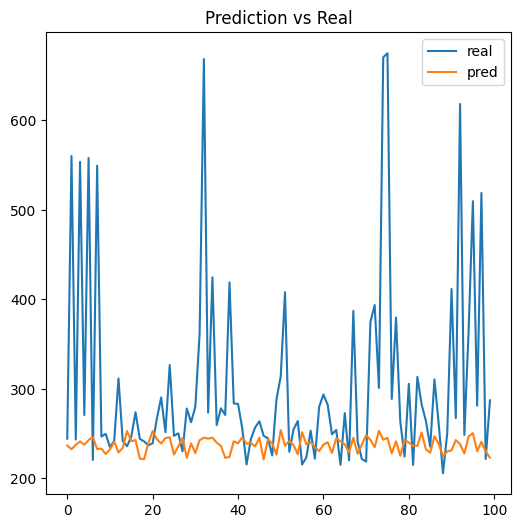

In [73]:

import numpy as np
import matplotlib.pyplot as plt


# convert lists to numpy arrays
real = np.array(actual_real_cost)
pred = np.array(actual_pred_cost)



plt.figure(  figsize=(6,6)  )

plt.plot( real[0:100] ,label="real")

plt.plot( pred[0:100] ,label="pred")

plt.legend()

plt.title("Prediction vs Real")

plt.show()


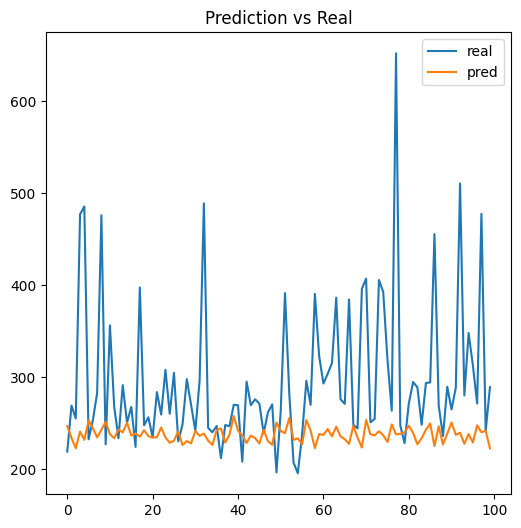

In [74]:

import numpy as np
import matplotlib.pyplot as plt


# convert lists to numpy arrays
real = np.array(actual_real_cost)
pred = np.array(actual_pred_cost)



plt.figure(  figsize=(6,6)  )

plt.plot( real[300:400] ,label="real")

plt.plot( pred[300:400] ,label="pred")

plt.legend()

plt.title("Prediction vs Real")

plt.show()


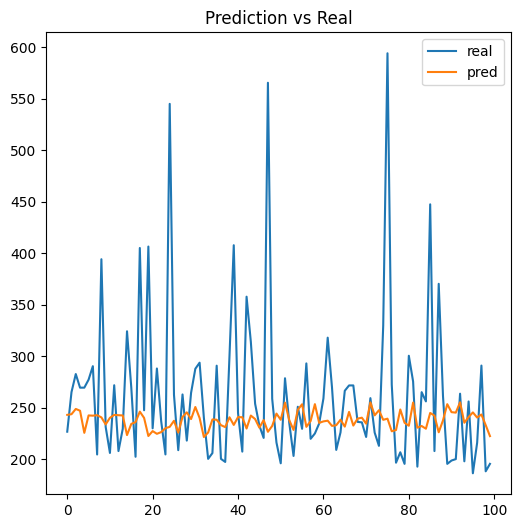

In [75]:

import numpy as np
import matplotlib.pyplot as plt


# convert lists to numpy arrays
real = np.array(actual_real_cost)
pred = np.array(actual_pred_cost)



plt.figure(  figsize=(6,6)  )

plt.plot( real[700:800] ,label="real")

plt.plot( pred[700:800] ,label="pred")

plt.legend()

plt.title("Prediction vs Real")

plt.show()


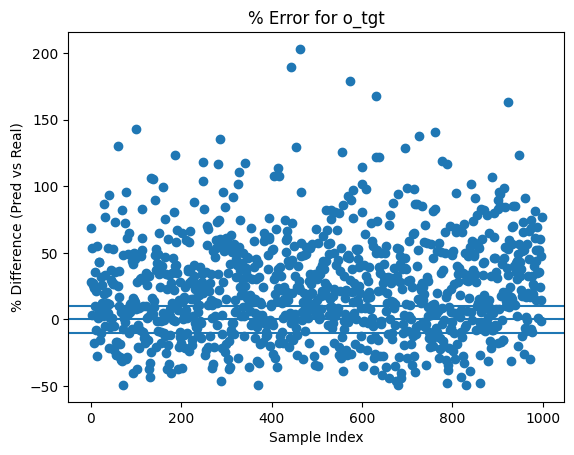

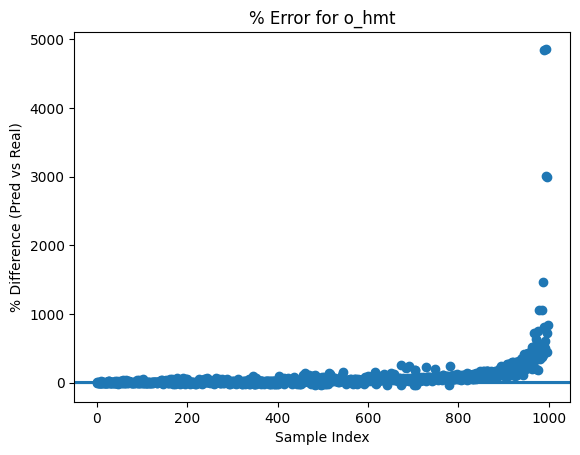

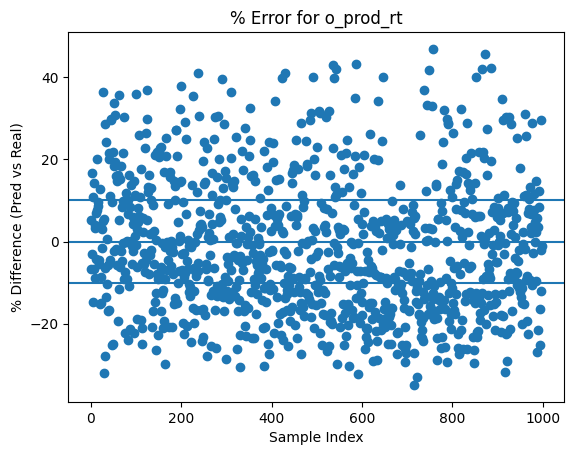

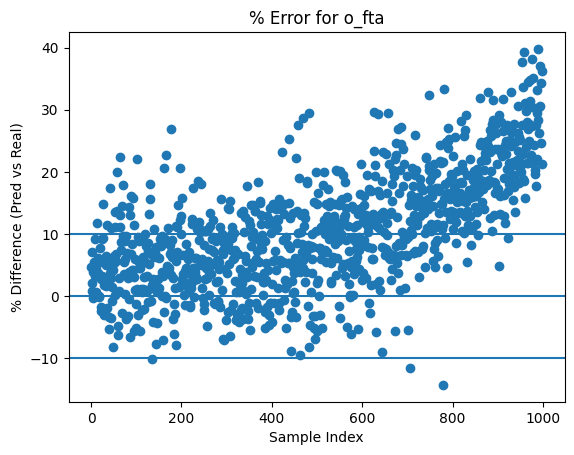

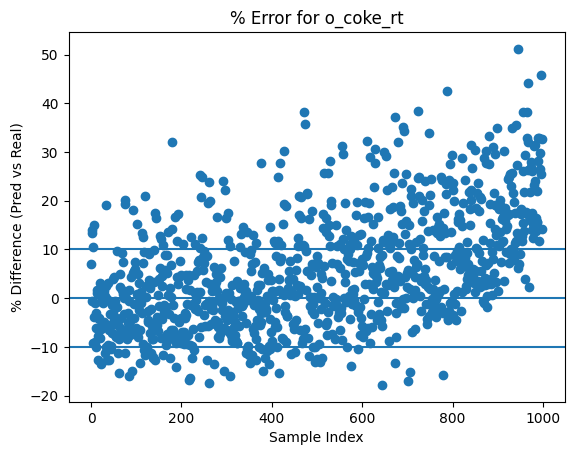

In [76]:

output_names = ['o_tgt', 'o_hmt', 'o_prod_rt', 'o_fta', 'o_coke_rt']

for k in range(5):
    plt.figure()
    plt.scatter(range(len(percent_errors[k])), percent_errors[k])
    
    plt.axhline(0)       # perfect prediction
    plt.axhline(10)      # +10% threshold
    plt.axhline(-10)     # -10% threshold
    
    plt.title(f"% Error for {output_names[k]}")
    plt.xlabel("Sample Index")
    plt.ylabel("% Difference (Pred vs Real)")
    
    plt.show()


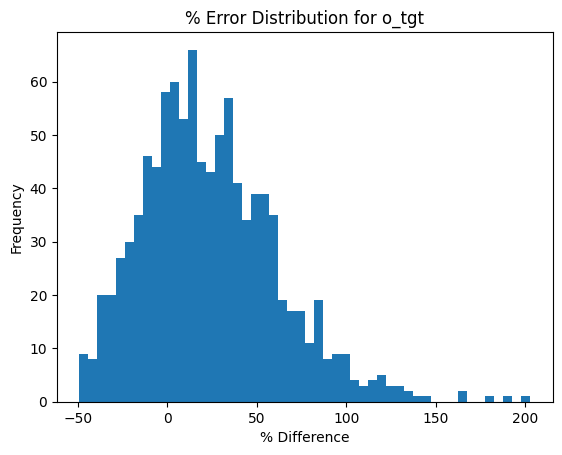

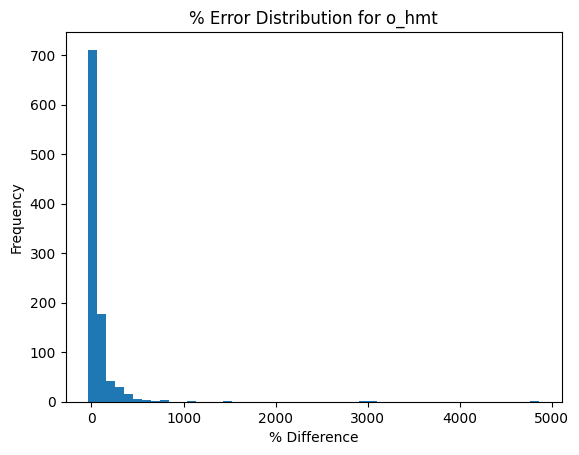

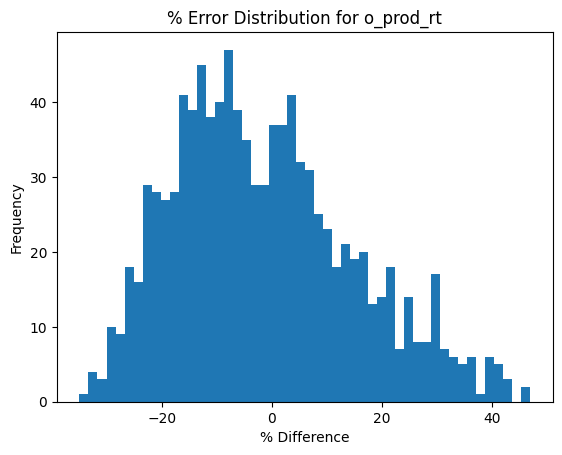

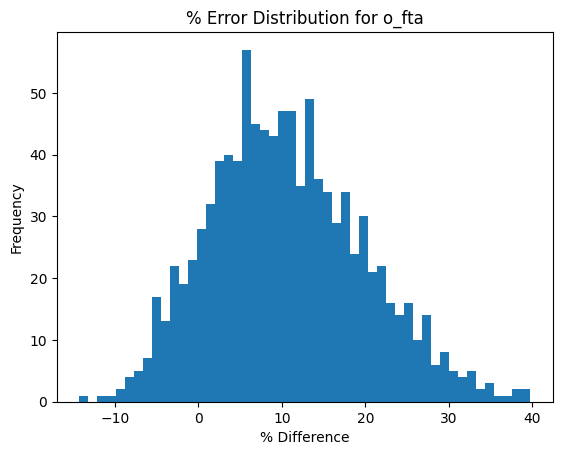

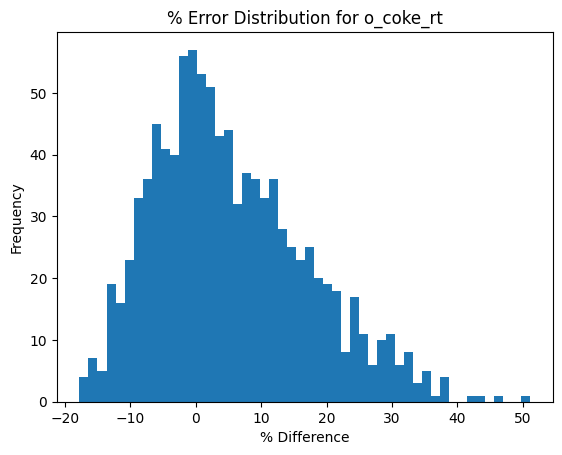

In [77]:

for k in range(5):
    plt.figure()
    plt.hist(percent_errors[k], bins=50)
    plt.title(f"% Error Distribution for {output_names[k]}")
    plt.xlabel("% Difference")
    plt.ylabel("Frequency")
    plt.show()


In [78]:

for k in range(5):
    vals = np.abs(percent_errors[k])
    within_10 = np.mean(vals <= 10) * 100
    within_5  = np.mean(vals <= 5) * 100

    print(output_names[k])
    print("  within 5% :", within_5)
    print("  within 10%:", within_10)


o_tgt
  within 5% : 12.212212212212211
  within 10%: 21.82182182182182
o_hmt
  within 5% : 8.90890890890891
  within 10%: 20.22022022022022
o_prod_rt
  within 5% : 19.81981981981982
  within 10%: 42.44244244244244
o_fta
  within 5% : 25.525525525525527
  within 10%: 49.74974974974975
o_coke_rt
  within 5% : 35.63563563563564
  within 10%: 61.76176176176176


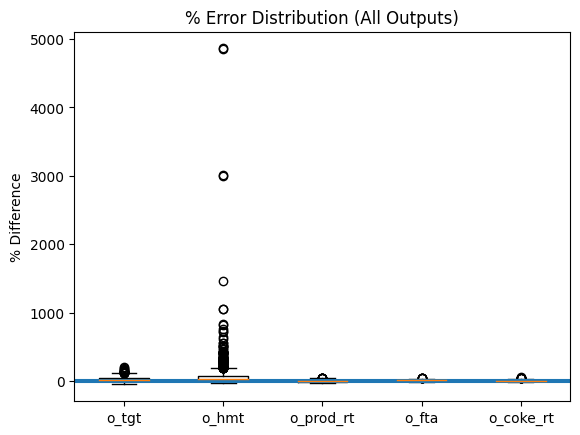

In [79]:

plt.figure()
plt.boxplot(percent_errors)
plt.xticks(range(1,6), output_names)
plt.axhline(10)
plt.axhline(-10)
plt.title("% Error Distribution (All Outputs)")
plt.ylabel("% Difference")
plt.show()


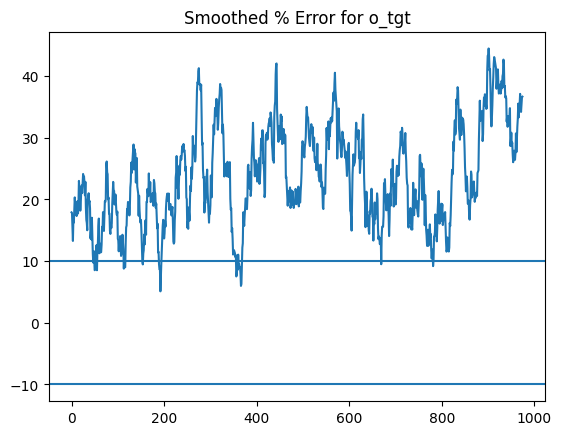

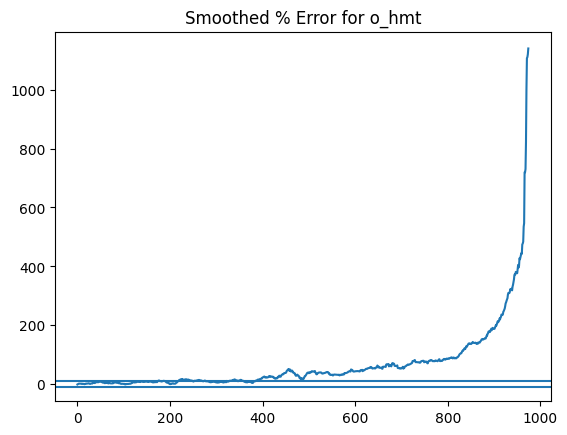

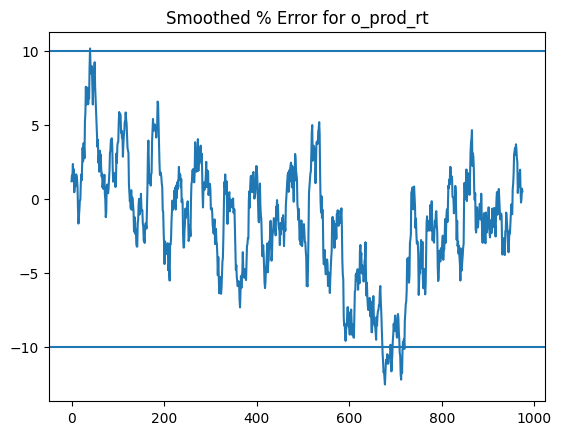

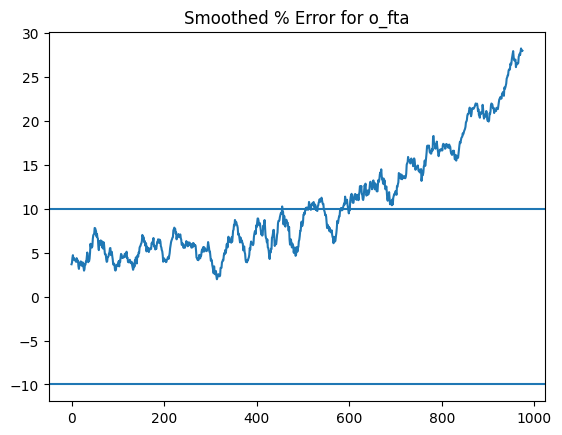

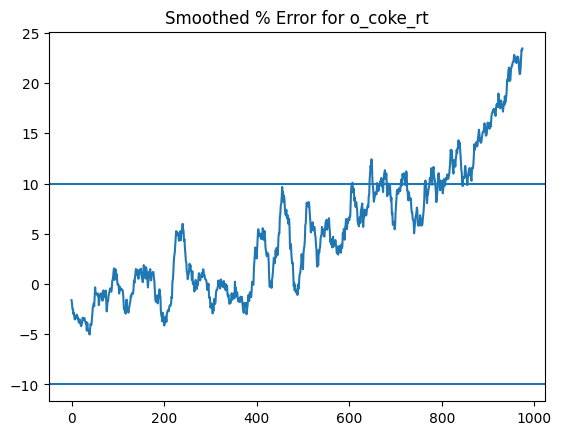

In [80]:

window = 25

for k in range(5):
    vals = np.array(percent_errors[k])
    smooth = np.convolve(vals, np.ones(window)/window, mode='valid')

    plt.figure()
    plt.plot(smooth)
    plt.axhline(10)
    plt.axhline(-10)

    plt.title(f"Smoothed % Error for {output_names[k]}")
    plt.show()


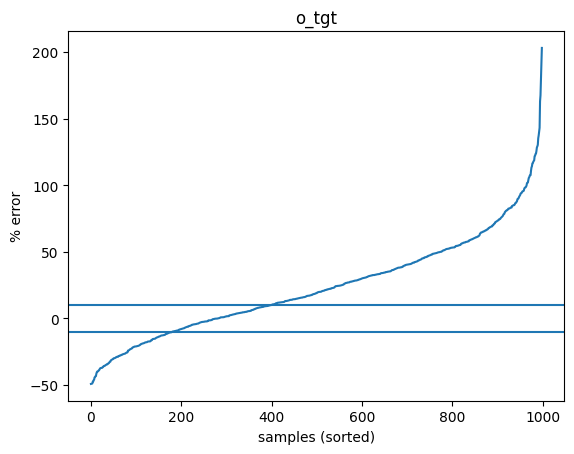

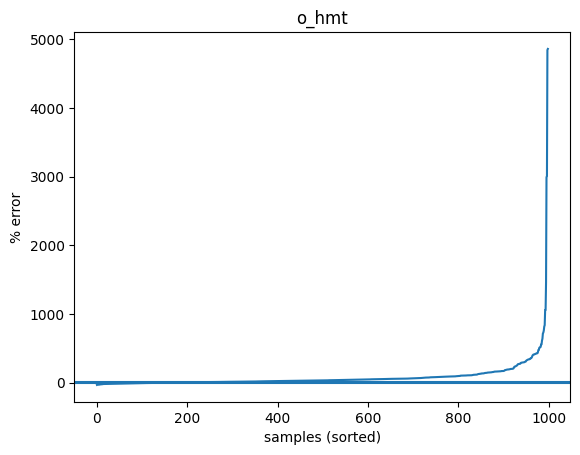

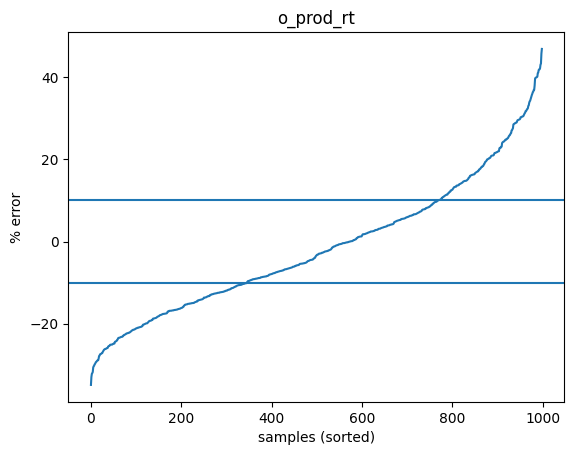

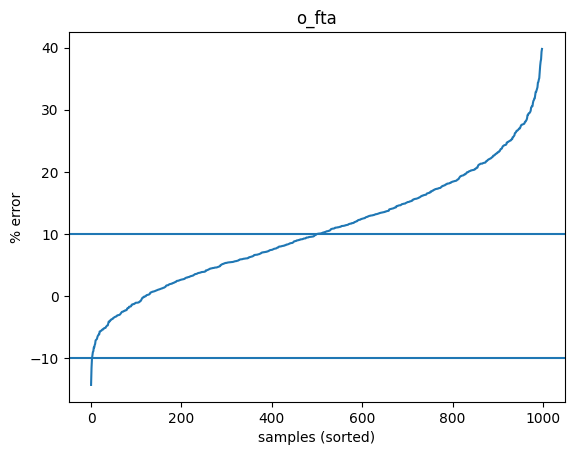

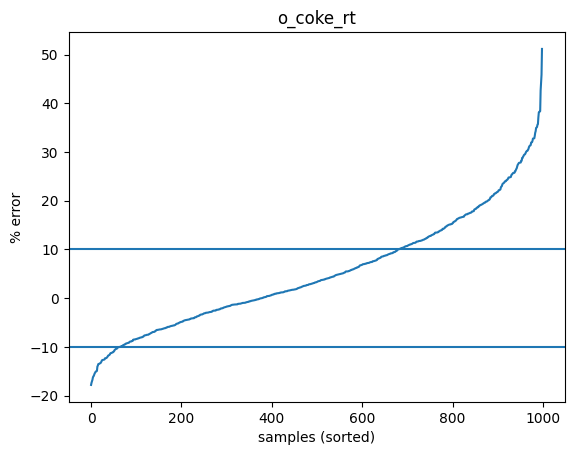

In [81]:

for k in range(5):
    vals = np.sort(np.array(percent_errors[k]))

    plt.figure()
    plt.plot(vals)
    plt.axhline(10)
    plt.axhline(-10)

    plt.title(output_names[k])
    plt.ylabel("% error")
    plt.xlabel("samples (sorted)")
    plt.show()


# 